In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Univariate fitting

Loads, summarizes, and plots persisted univariate experiment results.


In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import synthetic
from paper.plotting import plot_scaling, plot_target_gallery
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams["figure.dpi"] = 140


In [3]:
profile_name = "full"
raw_path = synthetic.default_raw_path("univariate", profile_name)
plot_target_kind = "monotone"

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.univariate first"
    )

raw = pd.read_csv(raw_path)

summary = summarize_raw(raw)
plot_summary = summary.loc[summary["target_kind"] == plot_target_kind].copy()
plot_summary.head()

,target_kind,complexity,noise_std,model,dim,batch_size,train_size,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
198,monotone,5,0.0,monotone,5,32,32,0.100000,0.590803,0.542652,0.701283,48
199,monotone,5,0.0,monotone,5,32,64,0.100000,0.444475,0.385712,0.564619,48
200,monotone,5,0.0,monotone,5,32,160,0.100000,0.277323,0.219905,0.353373,48
201,monotone,5,0.0,monotone,5,32,320,0.100000,0.226618,0.200571,0.290587,48
202,monotone,5,0.0,monotone,5,32,640,0.037276,0.217781,0.184464,0.280970,48


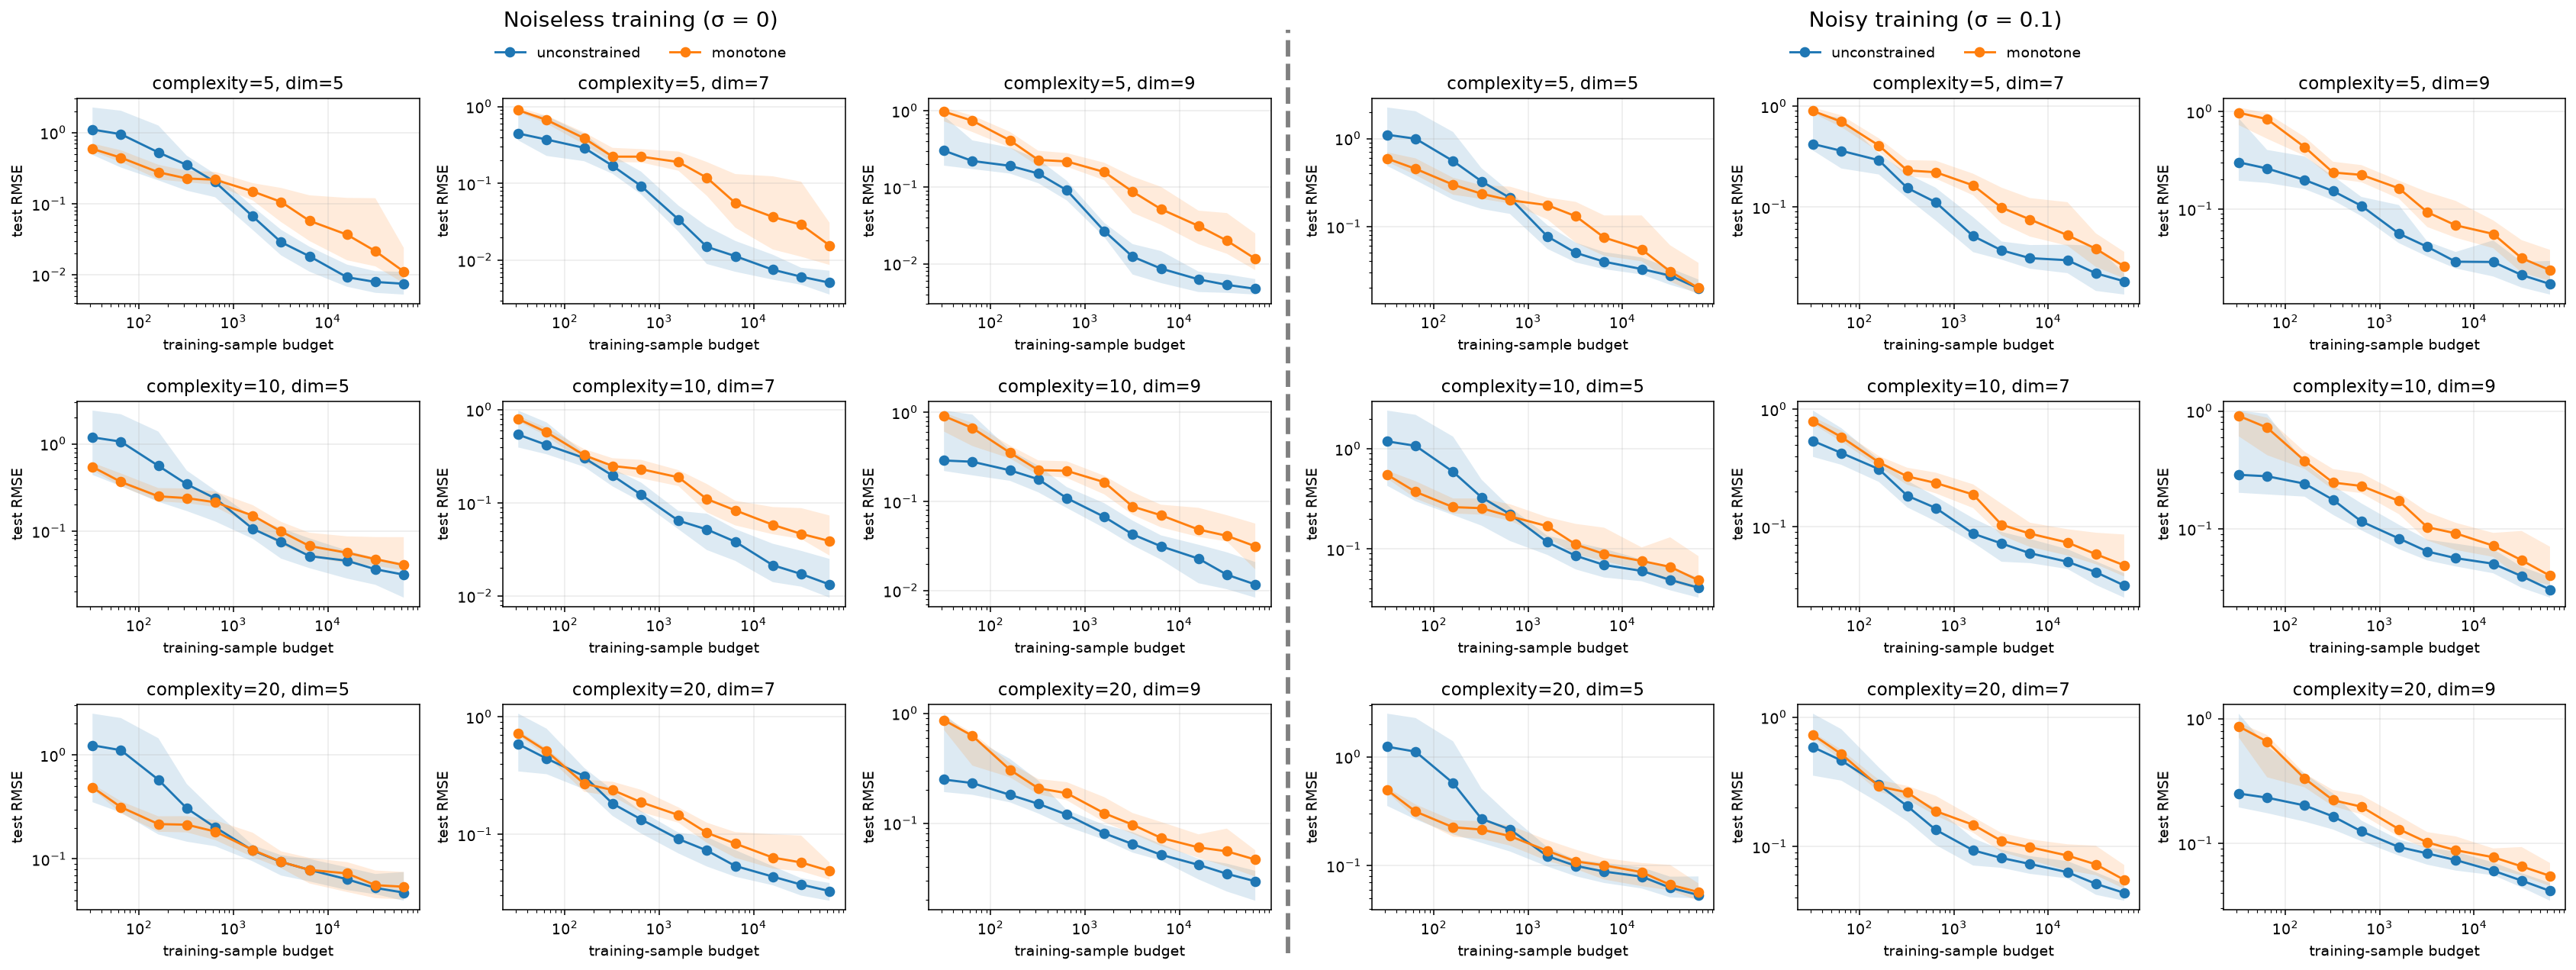

In [5]:
plot_scaling(plot_summary);

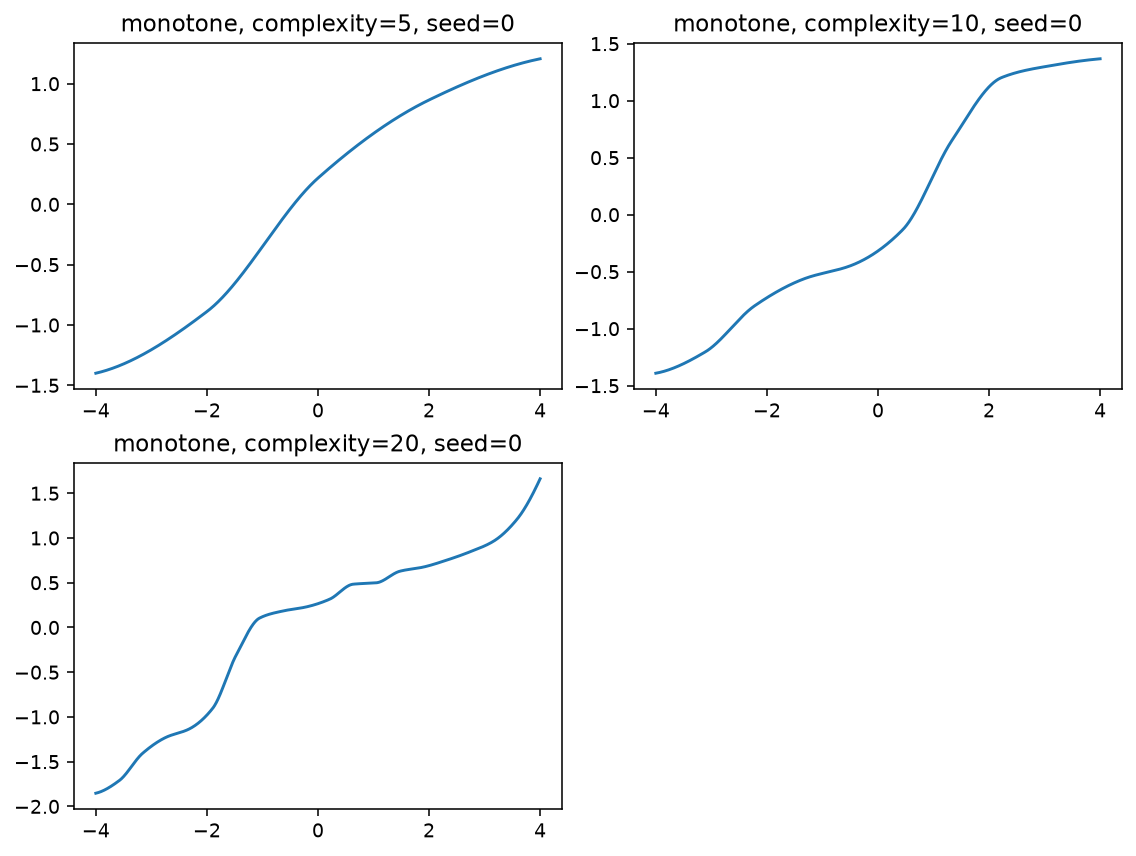

In [6]:
plot_target_gallery([
    TargetSpec(kind=plot_target_kind, complexity=complexity, seed=0)
    for complexity in sorted(plot_summary["complexity"].unique())
]);